# Deep Learning Model Comparison Implementation

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
# Download price data
tickers = ['KO', 'PEP']

prices = yf.download(tickers, start='2005-01-01', auto_adjust=False)['Adj Close']
prices.columns = ['KO', 'PEP']
prices = prices.dropna()

# Keep the recent 10 years so both models use the same period as the GRU notebook
prices = prices.loc['2015-01-01':].copy()

print(prices.head())
print(prices.tail())
print("Shape:", prices.shape)

[*********************100%***********************]  2 of 2 completed

                   KO        PEP
Date                            
2015-01-02  29.580011  67.283455
2015-01-05  29.580011  66.777618
2015-01-06  29.804632  66.271767
2015-01-07  30.176666  68.209618
2015-01-08  30.541681  69.449303
                   KO         PEP
Date                             
2026-04-16  75.180000  158.380005
2026-04-17  75.739998  157.669998
2026-04-20  75.480003  156.990005
2026-04-21  74.699997  154.919998
2026-04-22  74.764999  153.970001
Shape: (2842, 2)


## Common helper functions

In [7]:
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

lookback = 30
forecast_horizon = 10

## LSTM on simple returns

In [9]:
# Prepare returns
lstm_returns = prices.pct_change().dropna()

# Train-test split
lstm_train_size = int(len(lstm_returns) * 0.8)
lstm_train_returns = lstm_returns.iloc[:lstm_train_size]
lstm_test_returns = lstm_returns.iloc[lstm_train_size:]

# Scale
lstm_scaler = MinMaxScaler()
lstm_train_scaled = lstm_scaler.fit_transform(lstm_train_returns)
lstm_test_scaled = lstm_scaler.transform(lstm_test_returns)

# Sequences
X_train_lstm, y_train_lstm = create_sequences(lstm_train_scaled, lookback)
X_test_lstm, y_test_lstm = create_sequences(lstm_test_scaled, lookback)

print("LSTM X_train:", X_train_lstm.shape)
print("LSTM X_test :", X_test_lstm.shape)

LSTM X_train: (2242, 30, 2)
LSTM X_test : (539, 30, 2)


In [10]:
# Build and train LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, 2)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(2)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stop],
    verbose=0
)

print("LSTM training complete.")

LSTM training complete.


In [11]:
# LSTM test predictions
y_pred_scaled_lstm = lstm_model.predict(X_test_lstm, verbose=0)

y_test_returns_lstm = lstm_scaler.inverse_transform(y_test_lstm)
y_pred_returns_lstm = lstm_scaler.inverse_transform(y_pred_scaled_lstm)

lstm_test_index = lstm_test_returns.index[lookback:]

lstm_returns_results = pd.DataFrame(
    np.hstack([y_test_returns_lstm, y_pred_returns_lstm]),
    columns=['KO_Actual_Return', 'PEP_Actual_Return', 'KO_Pred_Return', 'PEP_Pred_Return'],
    index=lstm_test_index
)

# Convert predicted returns back to prices
ko_actual_prices = []
ko_pred_prices = []
pep_actual_prices = []
pep_pred_prices = []

for date in lstm_test_index:
    prev_price_row = prices.shift(1).loc[date]

    ko_prev_price = prev_price_row['KO']
    pep_prev_price = prev_price_row['PEP']

    ko_actual_price = ko_prev_price * (1 + lstm_returns_results.loc[date, 'KO_Actual_Return'])
    ko_pred_price = ko_prev_price * (1 + lstm_returns_results.loc[date, 'KO_Pred_Return'])

    pep_actual_price = pep_prev_price * (1 + lstm_returns_results.loc[date, 'PEP_Actual_Return'])
    pep_pred_price = pep_prev_price * (1 + lstm_returns_results.loc[date, 'PEP_Pred_Return'])

    ko_actual_prices.append(ko_actual_price)
    ko_pred_prices.append(ko_pred_price)
    pep_actual_prices.append(pep_actual_price)
    pep_pred_prices.append(pep_pred_price)

lstm_price_results = pd.DataFrame({
    'KO_Actual': ko_actual_prices,
    'KO_Predicted': ko_pred_prices,
    'PEP_Actual': pep_actual_prices,
    'PEP_Predicted': pep_pred_prices
}, index=lstm_test_index)

lstm_price_results.head()

,KO_Actual,KO_Predicted,PEP_Actual,PEP_Predicted
Date,,,,
2024-02-28,56.541546,56.527557,154.249969,155.377835
2024-02-29,56.185822,56.581373,153.854477,154.329359
2024-03-01,55.727127,56.223539,153.156570,153.928717
2024-03-04,55.989239,55.762721,153.882385,153.225399
2024-03-05,55.717758,56.021464,150.783707,153.937860


In [12]:
# LSTM 10-day forecast
full_scaled_lstm = lstm_scaler.transform(lstm_returns)
last_window_lstm = full_scaled_lstm[-lookback:].copy()

future_returns_scaled_lstm = []

for _ in range(forecast_horizon):
    x_input = last_window_lstm.reshape(1, lookback, 2)
    next_pred_scaled = lstm_model.predict(x_input, verbose=0)[0]
    future_returns_scaled_lstm.append(next_pred_scaled)
    last_window_lstm = np.vstack([last_window_lstm[1:], next_pred_scaled])

future_returns_scaled_lstm = np.array(future_returns_scaled_lstm)
future_returns_lstm = lstm_scaler.inverse_transform(future_returns_scaled_lstm)

future_returns_df_lstm = pd.DataFrame(
    future_returns_lstm,
    columns=['KO_Return_Forecast', 'PEP_Return_Forecast']
)

last_ko_price = prices['KO'].iloc[-1]
last_pep_price = prices['PEP'].iloc[-1]

ko_future_prices = []
pep_future_prices = []

ko_price = last_ko_price
pep_price = last_pep_price

for i in range(forecast_horizon):
    ko_price = ko_price * (1 + future_returns_df_lstm.loc[i, 'KO_Return_Forecast'])
    pep_price = pep_price * (1 + future_returns_df_lstm.loc[i, 'PEP_Return_Forecast'])
    ko_future_prices.append(ko_price)
    pep_future_prices.append(pep_price)

lstm_forecast_df = pd.DataFrame({
    'KO_Forecast': ko_future_prices,
    'PEP_Forecast': pep_future_prices
})

lstm_forecast_df.index = pd.bdate_range(
    start=prices.index[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon
)

lstm_forecast_df

,KO_Forecast,PEP_Forecast
2026-04-23,74.812164,154.038387
2026-04-24,74.854456,154.095872
2026-04-27,74.894633,154.147099
2026-04-28,74.934579,154.196069
2026-04-29,74.975425,154.245595
2026-04-30,75.017763,154.297404
2026-05-01,75.061798,154.352311
2026-05-04,75.107523,154.410556
2026-05-05,75.154781,154.471975
2026-05-06,75.203388,154.536263


## GRU on log returns

In [14]:
# Prepare log returns
gru_log_returns = np.log(prices / prices.shift(1)).dropna()

# Train-test split
gru_train_size = int(len(gru_log_returns) * 0.8)
gru_train_returns = gru_log_returns.iloc[:gru_train_size]
gru_test_returns = gru_log_returns.iloc[gru_train_size:]

# Scale
gru_scaler = MinMaxScaler()
gru_train_scaled = gru_scaler.fit_transform(gru_train_returns)
gru_test_scaled = gru_scaler.transform(gru_test_returns)

# Sequences
X_train_gru, y_train_gru = create_sequences(gru_train_scaled, lookback)
X_test_gru, y_test_gru = create_sequences(gru_test_scaled, lookback)

print("GRU X_train:", X_train_gru.shape)
print("GRU X_test :", X_test_gru.shape)

GRU X_train: (2242, 30, 2)
GRU X_test : (539, 30, 2)


In [15]:
# Build and train GRU model
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(lookback, 2)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(2)
])

gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train_gru, y_train_gru,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_gru, y_test_gru),
    callbacks=[early_stop],
    verbose=0
)

print("GRU training complete.")

GRU training complete.


In [16]:
# GRU test predictions
y_pred_scaled_gru = gru_model.predict(X_test_gru, verbose=0)

y_test_log_gru = gru_scaler.inverse_transform(y_test_gru)
y_pred_log_gru = gru_scaler.inverse_transform(y_pred_scaled_gru)

gru_test_index = gru_test_returns.index[lookback:]

gru_returns_results = pd.DataFrame(
    np.hstack([y_test_log_gru, y_pred_log_gru]),
    columns=['KO_Actual_LogRet', 'PEP_Actual_LogRet', 'KO_Pred_LogRet', 'PEP_Pred_LogRet'],
    index=gru_test_index
)

# Convert predicted log returns back to prices
ko_actual_prices = []
ko_pred_prices = []
pep_actual_prices = []
pep_pred_prices = []

for date in gru_test_index:
    prev_price_row = prices.shift(1).loc[date]

    ko_prev_price = prev_price_row['KO']
    pep_prev_price = prev_price_row['PEP']

    ko_actual_price = ko_prev_price * np.exp(gru_returns_results.loc[date, 'KO_Actual_LogRet'])
    ko_pred_price = ko_prev_price * np.exp(gru_returns_results.loc[date, 'KO_Pred_LogRet'])

    pep_actual_price = pep_prev_price * np.exp(gru_returns_results.loc[date, 'PEP_Actual_LogRet'])
    pep_pred_price = pep_prev_price * np.exp(gru_returns_results.loc[date, 'PEP_Pred_LogRet'])

    ko_actual_prices.append(ko_actual_price)
    ko_pred_prices.append(ko_pred_price)
    pep_actual_prices.append(pep_actual_price)
    pep_pred_prices.append(pep_pred_price)

gru_price_results = pd.DataFrame({
    'KO_Actual': ko_actual_prices,
    'KO_Predicted': ko_pred_prices,
    'PEP_Actual': pep_actual_prices,
    'PEP_Predicted': pep_pred_prices
}, index=gru_test_index)

gru_price_results.head()

,KO_Actual,KO_Predicted,PEP_Actual,PEP_Predicted
Date,,,,
2024-02-28,56.541546,56.529025,154.249969,155.364433
2024-02-29,56.185822,56.598015,153.854477,154.349881
2024-03-01,55.727127,56.241138,153.156570,153.954995
2024-03-04,55.989239,55.781245,153.882385,153.259971
2024-03-05,55.717758,56.034379,150.783707,153.942405


In [17]:
# GRU 10-day forecast
full_scaled_gru = gru_scaler.transform(gru_log_returns)
last_window_gru = full_scaled_gru[-lookback:].copy()

future_log_returns_scaled_gru = []

for _ in range(forecast_horizon):
    x_input = last_window_gru.reshape(1, lookback, 2)
    next_pred_scaled = gru_model.predict(x_input, verbose=0)[0]
    future_log_returns_scaled_gru.append(next_pred_scaled)
    last_window_gru = np.vstack([last_window_gru[1:], next_pred_scaled])

future_log_returns_scaled_gru = np.array(future_log_returns_scaled_gru)
future_log_returns_gru = gru_scaler.inverse_transform(future_log_returns_scaled_gru)

future_returns_df_gru = pd.DataFrame(
    future_log_returns_gru,
    columns=['KO_LogRet_Forecast', 'PEP_LogRet_Forecast']
)

last_ko_price = prices['KO'].iloc[-1]
last_pep_price = prices['PEP'].iloc[-1]

ko_future_prices = []
pep_future_prices = []

ko_price = last_ko_price
pep_price = last_pep_price

for i in range(forecast_horizon):
    ko_price = ko_price * np.exp(future_returns_df_gru.loc[i, 'KO_LogRet_Forecast'])
    pep_price = pep_price * np.exp(future_returns_df_gru.loc[i, 'PEP_LogRet_Forecast'])
    ko_future_prices.append(ko_price)
    pep_future_prices.append(pep_price)

gru_forecast_df = pd.DataFrame({
    'KO_Forecast': ko_future_prices,
    'PEP_Forecast': pep_future_prices
})

gru_forecast_df.index = pd.bdate_range(
    start=prices.index[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon
)

gru_forecast_df

,KO_Forecast,PEP_Forecast
2026-04-23,74.868164,154.129925
2026-04-24,74.953326,154.244375
2026-04-27,75.022091,154.319451
2026-04-28,75.080750,154.371365
2026-04-29,75.134694,154.413084
2026-04-30,75.187413,154.452365
2026-05-01,75.240788,154.493130
2026-05-04,75.295591,154.536778
2026-05-05,75.352050,154.583607
2026-05-06,75.410042,154.633233


## Metrics summary

In [19]:
# Metrics table
lstm_ko_metrics = evaluate_forecast(lstm_price_results['KO_Actual'], lstm_price_results['KO_Predicted'])
lstm_pep_metrics = evaluate_forecast(lstm_price_results['PEP_Actual'], lstm_price_results['PEP_Predicted'])

gru_ko_metrics = evaluate_forecast(gru_price_results['KO_Actual'], gru_price_results['KO_Predicted'])
gru_pep_metrics = evaluate_forecast(gru_price_results['PEP_Actual'], gru_price_results['PEP_Predicted'])

deep_metrics_df = pd.DataFrame([
    ['LSTM', 'KO', *lstm_ko_metrics],
    ['LSTM', 'PEP', *lstm_pep_metrics],
    ['GRU', 'KO', *gru_ko_metrics],
    ['GRU', 'PEP', *gru_pep_metrics],
], columns=['Model', 'Stock', 'MAE', 'RMSE', 'MAPE (%)'])

deep_metrics_df

,Model,Stock,MAE,RMSE,MAPE (%)
0,LSTM,KO,0.502858,0.667190,0.751626
1,LSTM,PEP,1.388539,1.877387,0.938053
2,GRU,KO,0.503107,0.666419,0.751878
3,GRU,PEP,1.389712,1.880746,0.938441


## Combined deep learning forecast plots

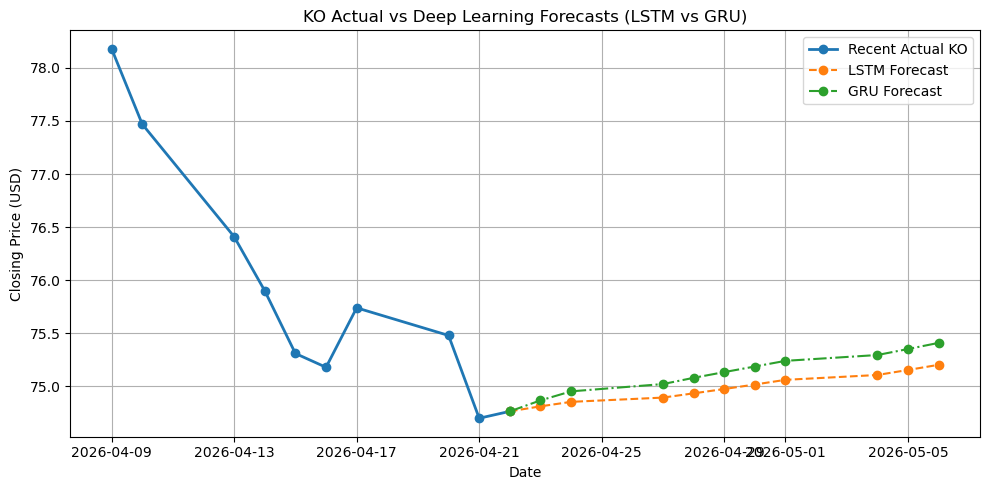

In [21]:
# Main report figure: KO combined forecast plot
plt.figure(figsize=(10, 5))

plt.plot(prices.index[-10:], prices['KO'].iloc[-10:],
         marker='o', linewidth=2, label='Recent Actual KO')

plt.plot([prices.index[-1]] + list(lstm_forecast_df.index),
         [prices['KO'].iloc[-1]] + list(lstm_forecast_df['KO_Forecast']),
         marker='o', linestyle='--', label='LSTM Forecast')

plt.plot([prices.index[-1]] + list(gru_forecast_df.index),
         [prices['KO'].iloc[-1]] + list(gru_forecast_df['KO_Forecast']),
         marker='o', linestyle='-.', label='GRU Forecast')

plt.title('KO Actual vs Deep Learning Forecasts (LSTM vs GRU)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

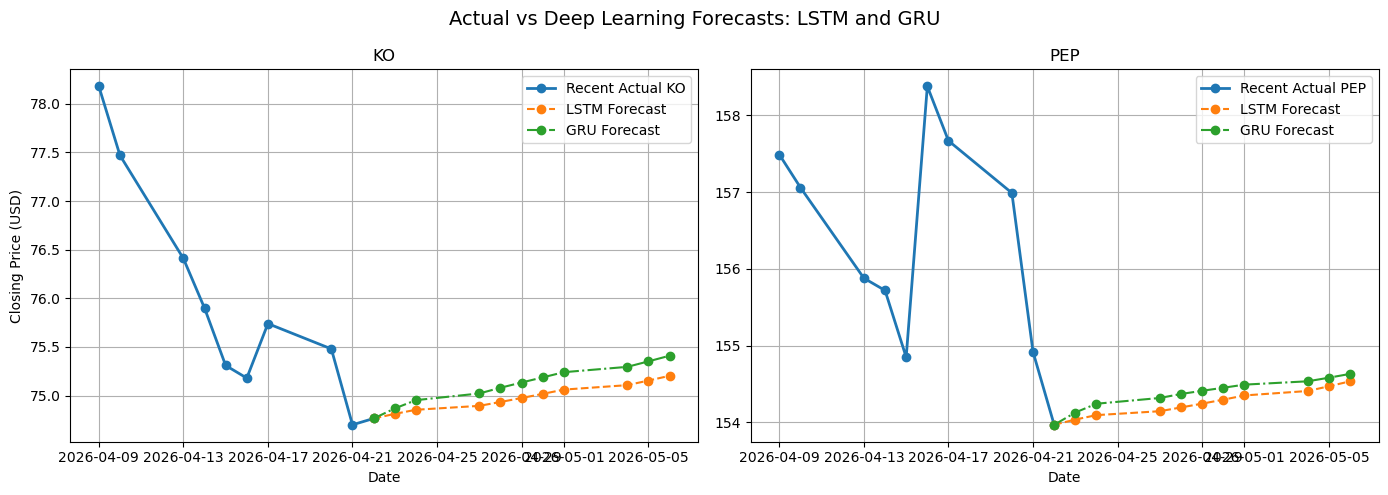

In [22]:
# Combined plot for KO and PEP together
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KO
axes[0].plot(prices.index[-10:], prices['KO'].iloc[-10:],
             marker='o', linewidth=2, label='Recent Actual KO')
axes[0].plot([prices.index[-1]] + list(lstm_forecast_df.index),
             [prices['KO'].iloc[-1]] + list(lstm_forecast_df['KO_Forecast']),
             marker='o', linestyle='--', label='LSTM Forecast')
axes[0].plot([prices.index[-1]] + list(gru_forecast_df.index),
             [prices['KO'].iloc[-1]] + list(gru_forecast_df['KO_Forecast']),
             marker='o', linestyle='-.', label='GRU Forecast')
axes[0].set_title('KO')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Closing Price (USD)')
axes[0].grid(True)
axes[0].legend()

# PEP
axes[1].plot(prices.index[-10:], prices['PEP'].iloc[-10:],
             marker='o', linewidth=2, label='Recent Actual PEP')
axes[1].plot([prices.index[-1]] + list(lstm_forecast_df.index),
             [prices['PEP'].iloc[-1]] + list(lstm_forecast_df['PEP_Forecast']),
             marker='o', linestyle='--', label='LSTM Forecast')
axes[1].plot([prices.index[-1]] + list(gru_forecast_df.index),
             [prices['PEP'].iloc[-1]] + list(gru_forecast_df['PEP_Forecast']),
             marker='o', linestyle='-.', label='GRU Forecast')
axes[1].set_title('PEP')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].legend()

plt.suptitle('Actual vs Deep Learning Forecasts: LSTM and GRU', fontsize=14)
plt.tight_layout()
plt.show()

## Train / Test / Actual-Predicted plots

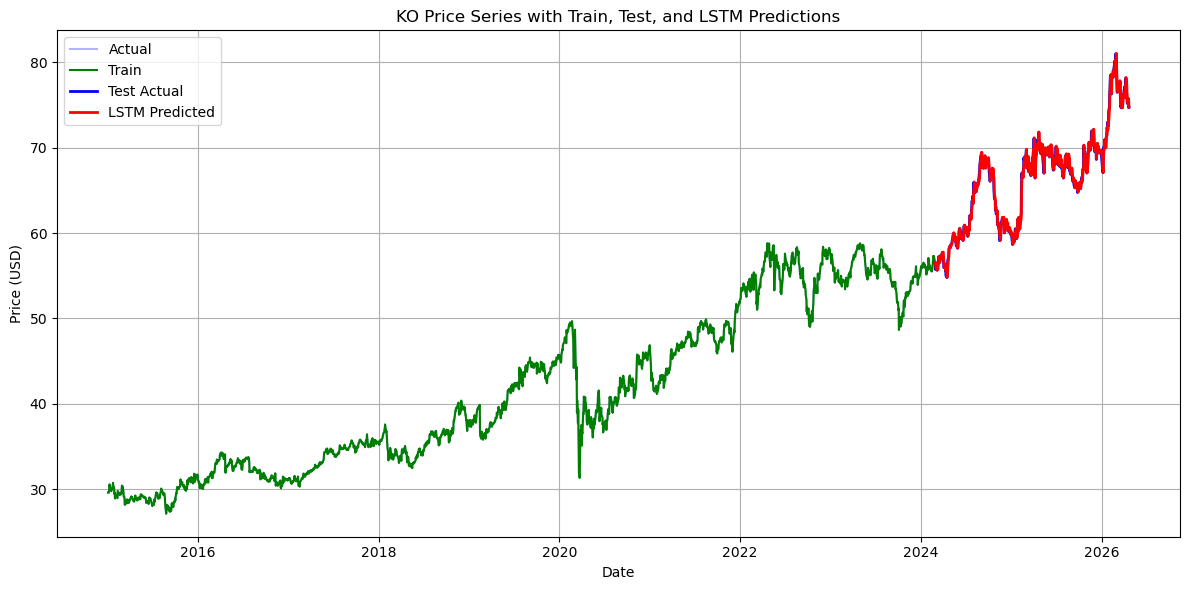

In [24]:
# LSTM train/test/prediction plot for KO
lstm_test_index = lstm_price_results.index
lstm_train_prices_ko = prices.loc[prices.index < lstm_test_index[0], 'KO']

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['KO'], color='blue', alpha=0.30, label='Actual')
plt.plot(lstm_train_prices_ko.index, lstm_train_prices_ko, color='green', label='Train')
plt.plot(lstm_price_results.index, lstm_price_results['KO_Actual'], color='blue', linewidth=2, label='Test Actual')
plt.plot(lstm_price_results.index, lstm_price_results['KO_Predicted'], color='red', linewidth=2, label='LSTM Predicted')
plt.title('KO Price Series with Train, Test, and LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

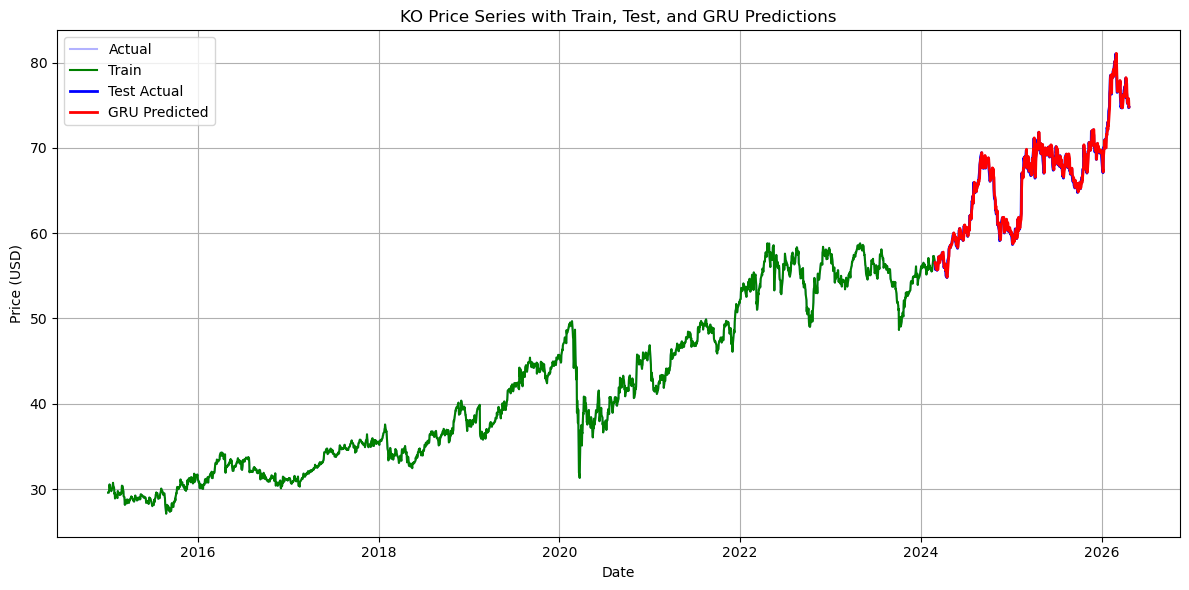

In [25]:
# GRU train/test/prediction plot for KO
gru_test_index = gru_price_results.index
gru_train_prices_ko = prices.loc[prices.index < gru_test_index[0], 'KO']

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['KO'], color='blue', alpha=0.30, label='Actual')
plt.plot(gru_train_prices_ko.index, gru_train_prices_ko, color='green', label='Train')
plt.plot(gru_price_results.index, gru_price_results['KO_Actual'], color='blue', linewidth=2, label='Test Actual')
plt.plot(gru_price_results.index, gru_price_results['KO_Predicted'], color='red', linewidth=2, label='GRU Predicted')
plt.title('KO Price Series with Train, Test, and GRU Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

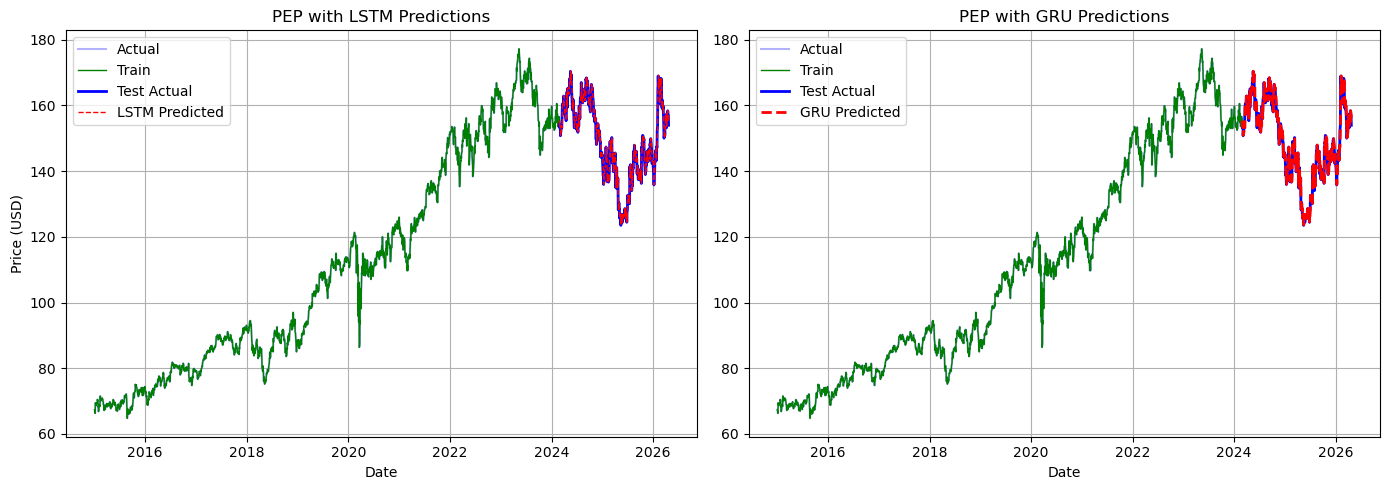

In [34]:
# PEP train/test/prediction plots for 2nd Review Meeting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lstm_train_prices_pep = prices.loc[prices.index < lstm_price_results.index[0], 'PEP']
axes[0].plot(prices.index, prices['PEP'], color='blue', alpha=0.30, label='Actual')
axes[0].plot(lstm_train_prices_pep.index, lstm_train_prices_pep, color='green', linewidth=1, label='Train')
axes[0].plot(lstm_price_results.index, lstm_price_results['PEP_Actual'], color='blue', linewidth=2, label='Test Actual')
axes[0].plot(lstm_price_results.index, lstm_price_results['PEP_Predicted'], color='red', linewidth=1, linestyle='--', label='LSTM Predicted')
axes[0].set_title('PEP with LSTM Predictions')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)
axes[0].legend()

gru_train_prices_pep = prices.loc[prices.index < gru_price_results.index[0], 'PEP']
axes[1].plot(prices.index, prices['PEP'], color='blue', alpha=0.30, label='Actual')
axes[1].plot(gru_train_prices_pep.index, gru_train_prices_pep, color='green', linewidth=1, label='Train')
axes[1].plot(gru_price_results.index, gru_price_results['PEP_Actual'], color='blue', linewidth=2, label='Test Actual')
axes[1].plot(gru_price_results.index, gru_price_results['PEP_Predicted'], color='red', linewidth=2, linestyle='--', label='GRU Predicted')
axes[1].set_title('PEP with GRU Predictions')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# Test index fetches from implemented model results
test_index = price_results.index

# Define train prices
train_prices = prices.loc[prices.index < test_index[0], 'KO']

# Test actual values (from results)
test_actual = price_results['KO_Actual']

# Model predictions
test_pred = price_results['KO_Predicted']

NameError: name 'price_results' is not defined

In [ ]:
print([v for v in globals() if 'test' in v.lower() or 'pred' in v.lower() or 'price' in v.lower()])

In [ ]:
# PEP train/test/prediction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lstm_train_prices_pep = prices.loc[prices.index < lstm_price_results.index[0], 'PEP']
axes[0].plot(prices.index, prices['PEP'], color='Blue', linewidth=2, alpha=0.4, label='Actual (Full Series)')
axes[0].plot(lstm_train_prices_pep.index, lstm_train_prices_pep, color='green',linewidth=0.5, label='Train')
axes[0].plot(lstm_price_results.index, lstm_price_results['PEP_Actual'], color='Orange', linewidth=0.5, label='Test Actual')
axes[0].plot(lstm_price_results.index, lstm_price_results['PEP_Predicted'], color='red', linewidth=0., linestyle='--', label='LSTM Predicted')
axes[0].set_title('PEP with LSTM Predictions')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)
axes[0].legend()

gru_train_prices_pep = prices.loc[prices.index < gru_price_results.index[0], 'PEP']
axes[1].plot(prices.index, prices['PEP'], color='blue', alpha=0.30, label='Actual')
axes[1].plot(gru_train_prices_pep.index, gru_train_prices_pep, color='green', label='Train')
axes[1].plot(gru_price_results.index, gru_price_results['PEP_Actual'], color='blue', linewidth=2, label='Test Actual')
axes[1].plot(gru_price_results.index, gru_price_results['PEP_Predicted'], color='red', linewidth=2, label='GRU Predicted')
axes[1].set_title('PEP with GRU Predictions')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print([v for v in globals() if 'test' in v.lower() or 'pred' in v.lower() or 'price' in v.lower()])

In [ ]:
# Last 10 Days Actual vs Predicted Table for KO by LSTM

import pandas as pd

last_10_table = pd.DataFrame({
    'Actual Price': ko_actual_prices,
    'Predicted Price': ko_pred_prices
}, index=lstm_test_index)

# Keep only last 10 rows
last_10_table = last_10_table.tail(10).copy()

# Calculate errors
last_10_table['Absolute Error'] = (last_10_table['Actual Price'] - last_10_table['Predicted Price']).abs()
last_10_table['Error (%)'] = (last_10_table['Absolute Error'] / last_10_table['Actual Price']) * 100

# Round for presentation
last_10_table = last_10_table.round(2)

# Make date a normal column
last_10_table = last_10_table.reset_index().rename(columns={'index': 'Date'})

print("Last 10 Days Actual vs Predicted Prices for KO (LSTM)")
display(last_10_table)

# Optional: save to CSV
last_10_table.to_csv("KO_Last_10_Days_LSTM.csv", index=False)

In [ ]:
# Last 10 Days Actual vs Predicted Table for KO by GRU

import pandas as pd

last_10_table_gru = pd.DataFrame({
    'Actual Price': gru_price_results['KO_Actual'],
    'Predicted Price': gru_price_results['KO_Predicted']
}, index=gru_price_results.index)

# Keep only last 10 rows
last_10_table_gru = last_10_table_gru.tail(10).copy()

# Calculate errors
last_10_table_gru['Absolute Error'] = (last_10_table_gru['Actual Price'] - last_10_table_gru['Predicted Price']).abs()
last_10_table_gru['Error (%)'] = (last_10_table_gru['Absolute Error'] / last_10_table_gru['Actual Price']) * 100

# Round for presentation
last_10_table_gru = last_10_table_gru.round(2)

# Make date a normal column
last_10_table_gru = last_10_table_gru.reset_index().rename(columns={'index': 'Date'})

print("Last 10 Days Actual vs Predicted Prices for KO (GRU)")
display(last_10_table_gru)

# Optional: save to CSV
last_10_table_gru.to_csv("KO_Last_10_Days_GRU.csv", index=False)

In [ ]:
print(lstm_price_results.head())
print(gru_price_results.head())

In [ ]:
# KO Last 10 Days (LSTM vs GRU)

import pandas as pd

# Combine both model outputs
combined_last_10 = pd.DataFrame({
    'Actual Price': lstm_price_results['KO_Actual'],
    'LSTM Predicted': lstm_price_results['KO_Predicted'],
    'GRU Predicted': gru_price_results['KO_Predicted']
}, index=lstm_price_results.index)

# Keep only last 10 rows
combined_last_10 = combined_last_10.tail(10).copy()

# Calculate errors
combined_last_10['LSTM Error (%)'] = (
    abs(combined_last_10['Actual Price'] - combined_last_10['LSTM Predicted']) 
    / combined_last_10['Actual Price']
) * 100

combined_last_10['GRU Error (%)'] = (
    abs(combined_last_10['Actual Price'] - combined_last_10['GRU Predicted']) 
    / combined_last_10['Actual Price']
) * 100

# Round values
combined_last_10 = combined_last_10.round(2)

# Reset index to Date column
combined_last_10 = combined_last_10.reset_index().rename(columns={'index': 'Date'})

# Display
print("Last 10 Days KO Price Prediction Comparison (LSTM vs GRU)")
display(combined_last_10)

# Optional export
combined_last_10.to_csv("KO_Last_10_Days_LSTM_vs_GRU.csv", index=False)

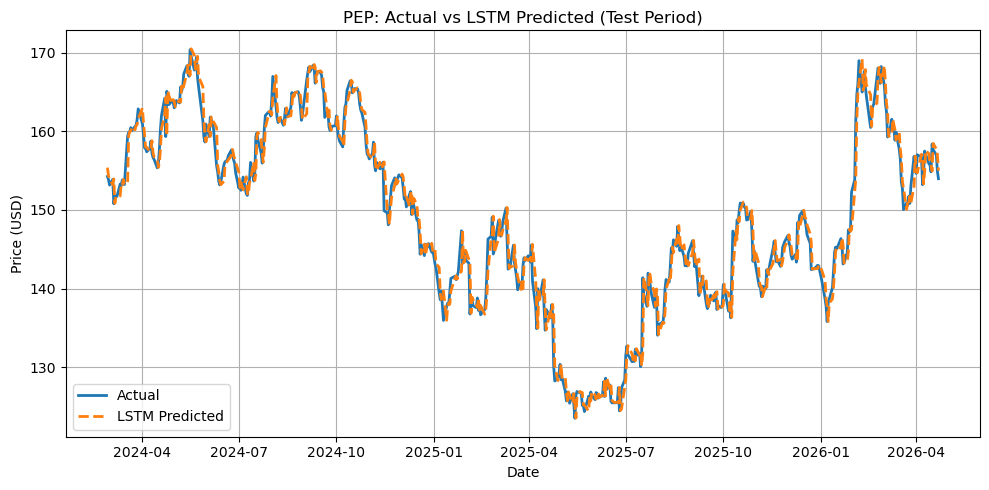

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_price_results.index,
    lstm_price_results['PEP_Actual'],
    label='Actual',
    linewidth=2
)

plt.plot(
    lstm_price_results.index,
    lstm_price_results['PEP_Predicted'],
    label='LSTM Predicted',
    linestyle='--',
    linewidth=2
)

plt.title('PEP: Actual vs LSTM Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

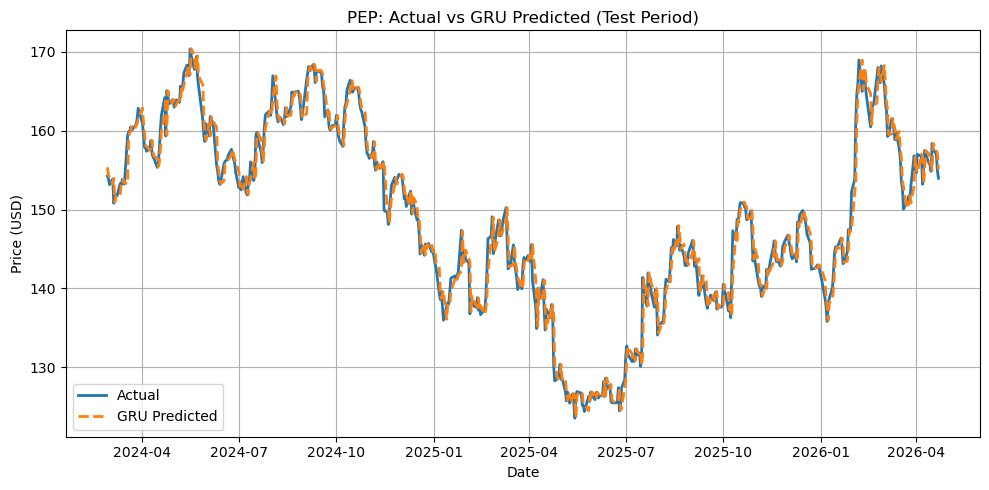

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    gru_price_results.index,
    gru_price_results['PEP_Actual'],
    label='Actual',
    linewidth=2
)

plt.plot(
    gru_price_results.index,
    gru_price_results['PEP_Predicted'],
    label='GRU Predicted',
    linestyle='--',
    linewidth=2
)

plt.title('PEP: Actual vs GRU Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

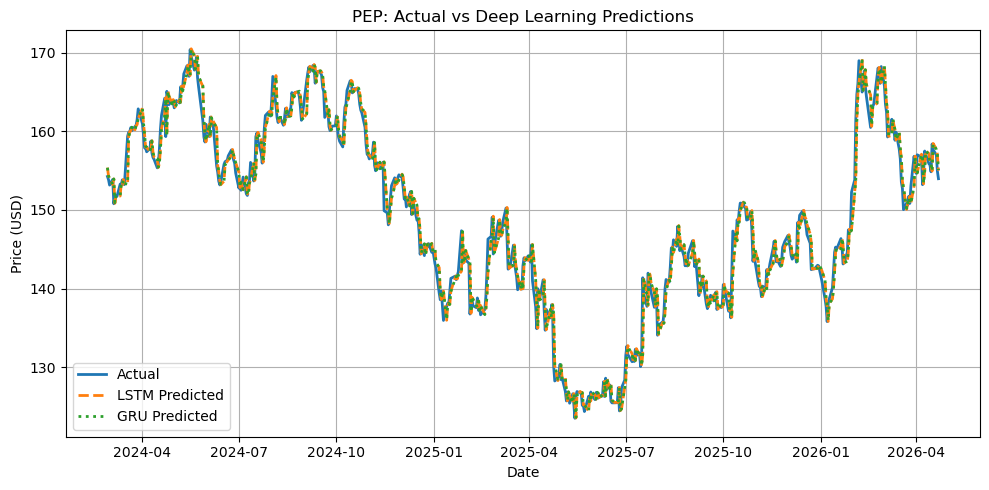

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_price_results.index,
    lstm_price_results['PEP_Actual'],
    label='Actual',
    linewidth=2
)

plt.plot(
    lstm_price_results.index,
    lstm_price_results['PEP_Predicted'],
    label='LSTM Predicted',
    linestyle='--',
    linewidth=2
)

plt.plot(
    gru_price_results.index,
    gru_price_results['PEP_Predicted'],
    label='GRU Predicted',
    linestyle=':',
    linewidth=2
)

plt.title('PEP: Actual vs Deep Learning Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

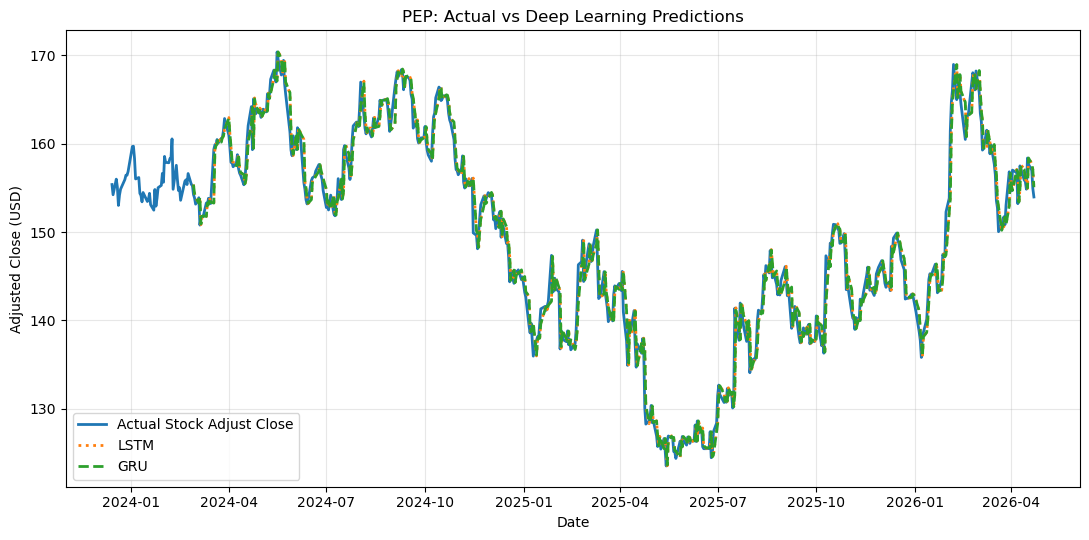

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

ticker = 'PEP'
history_days = 50   # number of historical days to show before forecast window

# Forecast start date
forecast_start = lstm_price_results.index.min()

# Historical tail before forecast starts
history_tail = prices.loc[prices.index < forecast_start, ticker].tail(history_days)

# Actual values in forecast window
actual_forecast = lstm_price_results[f'{ticker}_Actual']

# Predicted values
lstm_forecast = lstm_price_results[f'{ticker}_Predicted']
gru_forecast  = gru_price_results[f'{ticker}_Predicted']

plt.figure(figsize=(11, 5.5))

# Actual history + test period as one continuous blue line
actual_combined = pd.concat([history_tail, actual_forecast])
plt.plot(
    actual_combined.index,
    actual_combined.values,
    label='Actual Stock Adjust Close',
    linewidth=2
)

# Forecast lines only over prediction horizon
plt.plot(
    lstm_forecast.index,
    lstm_forecast.values,
    label='LSTM',
    linestyle=':',
    linewidth=2
)

plt.plot(
    gru_forecast.index,
    gru_forecast.values,
    label='GRU',
    linestyle='--',
    linewidth=2
)

plt.title(f'{ticker}: Actual vs Deep Learning Predictions')
plt.xlabel('Date')
plt.ylabel('Adjusted Close (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

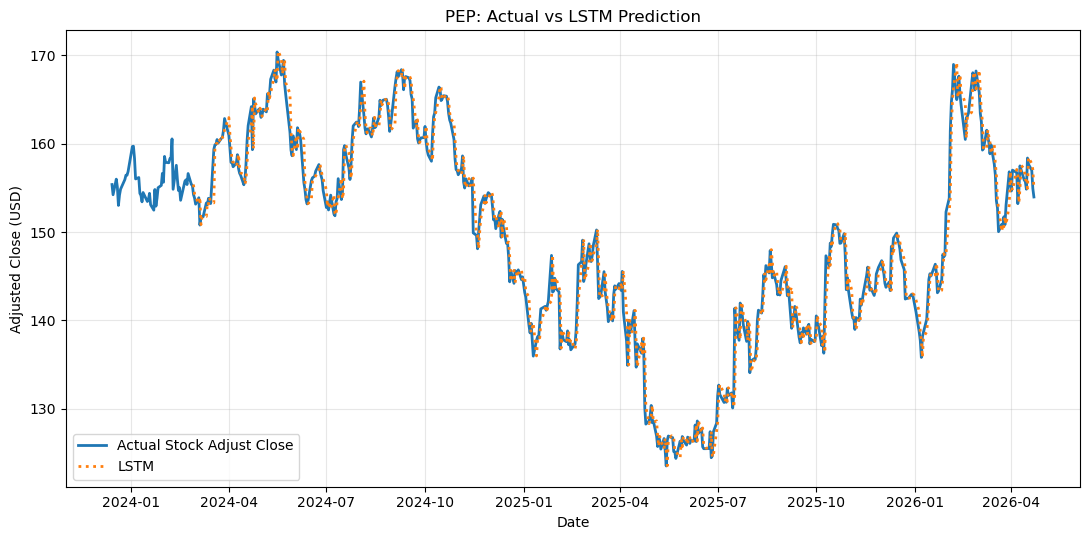

In [44]:
ticker = 'PEP'
history_days = 50

forecast_start = lstm_price_results.index.min()
history_tail = prices.loc[prices.index < forecast_start, ticker].tail(history_days)

actual_forecast = lstm_price_results[f'{ticker}_Actual']
lstm_forecast = lstm_price_results[f'{ticker}_Predicted']

plt.figure(figsize=(11, 5.5))

actual_combined = pd.concat([history_tail, actual_forecast])
plt.plot(
    actual_combined.index,
    actual_combined.values,
    label='Actual Stock Adjust Close',
    linewidth=2
)

plt.plot(
    lstm_forecast.index,
    lstm_forecast.values,
    label='LSTM',
    linestyle=':',
    linewidth=2
)

plt.title(f'{ticker}: Actual vs LSTM Prediction')
plt.xlabel('Date')
plt.ylabel('Adjusted Close (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

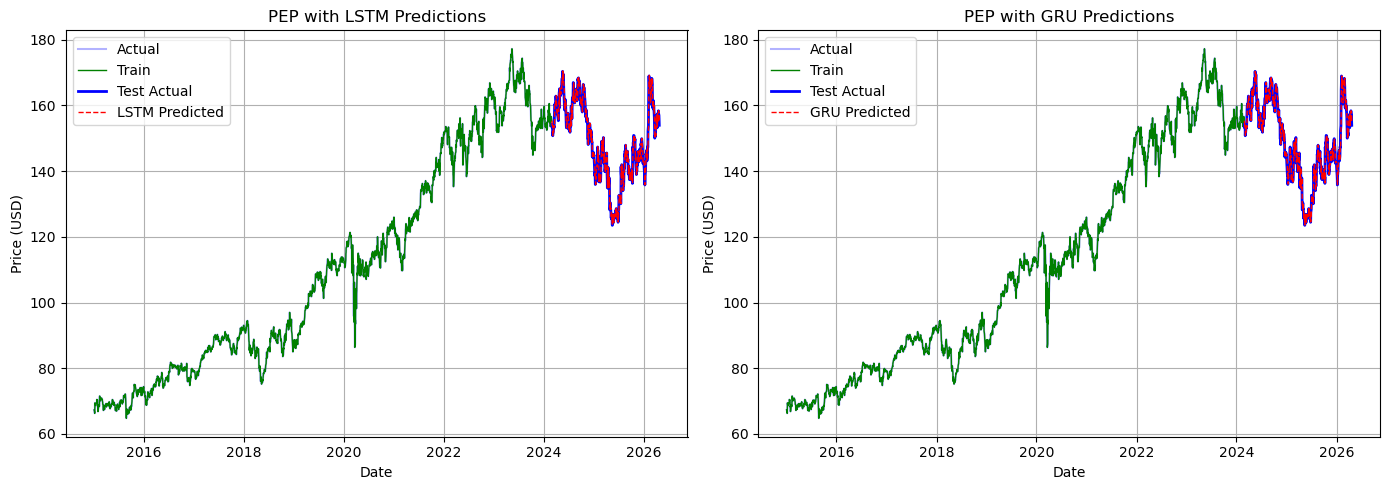

In [46]:
# PEP train/test/prediction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LSTM subplot
lstm_train_prices_pep = prices.loc[prices.index < lstm_price_results.index[0], 'PEP']

axes[0].plot(
    prices.index, prices['PEP'],
    color='blue', alpha=0.30, label='Actual'
)
axes[0].plot(
    lstm_train_prices_pep.index, lstm_train_prices_pep,
    color='green', linewidth=1, label='Train'
)
axes[0].plot(
    lstm_price_results.index, lstm_price_results['PEP_Actual'],
    color='blue', linewidth=2, label='Test Actual'
)
axes[0].plot(
    lstm_price_results.index, lstm_price_results['PEP_Predicted'],
    color='red', linewidth=1, linestyle='--', label='LSTM Predicted'
)
axes[0].set_title('PEP with LSTM Predictions')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)
axes[0].legend()

# GRU subplot
gru_train_prices_pep = prices.loc[prices.index < gru_price_results.index[0], 'PEP']

axes[1].plot(
    prices.index, prices['PEP'],
    color='blue', alpha=0.30, label='Actual'
)
axes[1].plot(
    gru_train_prices_pep.index, gru_train_prices_pep,
    color='green', linewidth=1, label='Train'
)
axes[1].plot(
    gru_price_results.index, gru_price_results['PEP_Actual'],
    color='blue', linewidth=2, label='Test Actual'
)
axes[1].plot(
    gru_price_results.index, gru_price_results['PEP_Predicted'],
    color='red', linewidth=1, linestyle='--', label='GRU Predicted'
)
axes[1].set_title('PEP with GRU Predictions')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

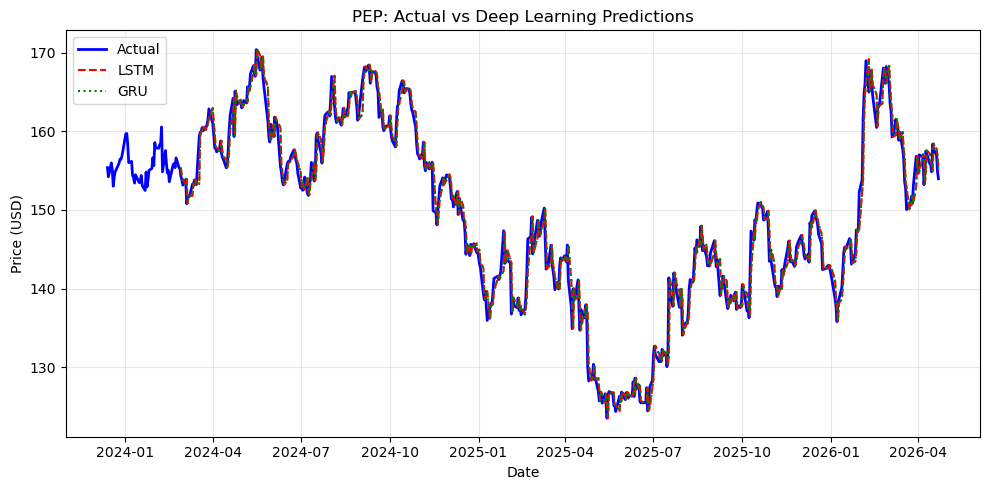

In [50]:
plt.figure(figsize=(10, 5))

# Actual
plt.plot(
    lstm_actual_combined.index,
    lstm_actual_combined.values,
    color='blue',
    linewidth=2,
    label='Actual'
)

# LSTM
plt.plot(
    lstm_price_results.index,
    lstm_price_results['PEP_Predicted'],
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='LSTM'
)

# GRU
plt.plot(
    gru_price_results.index,
    gru_price_results['PEP_Predicted'],
    color='green',
    linewidth=1.5,
    linestyle=':',
    label='GRU'
)

plt.title('PEP: Actual vs Deep Learning Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

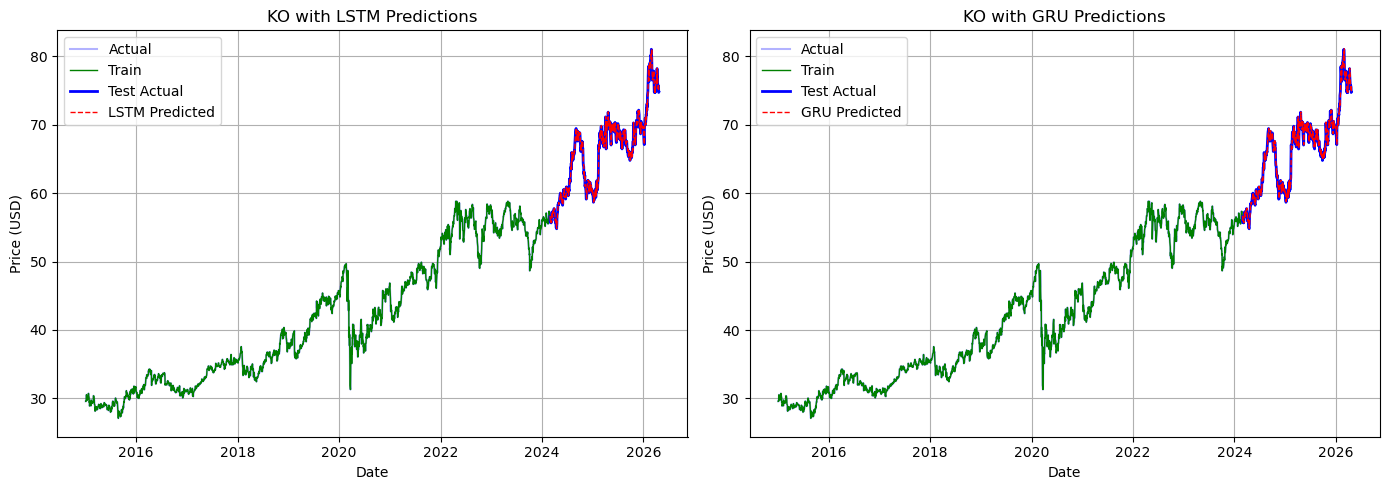

In [52]:
# KO train/test/prediction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LSTM subplot
lstm_train_prices_ko = prices.loc[prices.index < lstm_price_results.index[0], 'KO']

axes[0].plot(
    prices.index, prices['KO'],
    color='blue', alpha=0.30, label='Actual'
)
axes[0].plot(
    lstm_train_prices_ko.index, lstm_train_prices_ko,
    color='green', linewidth=1, label='Train'
)
axes[0].plot(
    lstm_price_results.index, lstm_price_results['KO_Actual'],
    color='blue', linewidth=2, label='Test Actual'
)
axes[0].plot(
    lstm_price_results.index, lstm_price_results['KO_Predicted'],
    color='red', linewidth=1, linestyle='--', label='LSTM Predicted'
)
axes[0].set_title('KO with LSTM Predictions')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)
axes[0].legend()

# GRU subplot
gru_train_prices_ko = prices.loc[prices.index < gru_price_results.index[0], 'KO']

axes[1].plot(
    prices.index, prices['KO'],
    color='blue', alpha=0.30, label='Actual'
)
axes[1].plot(
    gru_train_prices_ko.index, gru_train_prices_ko,
    color='green', linewidth=1, label='Train'
)
axes[1].plot(
    gru_price_results.index, gru_price_results['KO_Actual'],
    color='blue', linewidth=2, label='Test Actual'
)
axes[1].plot(
    gru_price_results.index, gru_price_results['KO_Predicted'],
    color='red', linewidth=1, linestyle='--', label='GRU Predicted'
)
axes[1].set_title('KO with GRU Predictions')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
len(lstm_price_results)

539

In [56]:
print("----- FULL DATA -----")
print("Total observations:", len(prices))

print("\n----- LSTM -----")
print("Train:", len(prices.loc[prices.index < lstm_price_results.index[0]]))
print("Test Actual KO:", len(lstm_price_results['KO_Actual']))
print("Test Actual PEP:", len(lstm_price_results['PEP_Actual']))
print("Predicted KO:", len(lstm_price_results['KO_Predicted']))
print("Predicted PEP:", len(lstm_price_results['PEP_Predicted']))

print("\n----- GRU -----")
print("Train:", len(prices.loc[prices.index < gru_price_results.index[0]]))
print("Test Actual KO:", len(gru_price_results['KO_Actual']))
print("Test Actual PEP:", len(gru_price_results['PEP_Actual']))
print("Predicted KO:", len(gru_price_results['KO_Predicted']))
print("Predicted PEP:", len(gru_price_results['PEP_Predicted']))

----- FULL DATA -----
Total observations: 2842

----- LSTM -----
Train: 2303
Test Actual KO: 539
Test Actual PEP: 539
Predicted KO: 539
Predicted PEP: 539

----- GRU -----
Train: 2303
Test Actual KO: 539
Test Actual PEP: 539
Predicted KO: 539
Predicted PEP: 539


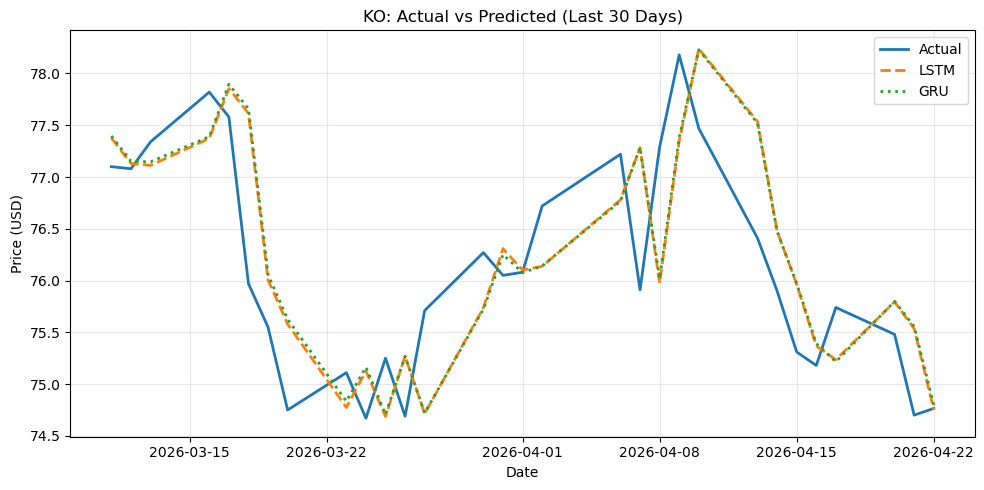

In [58]:
import matplotlib.pyplot as plt

window = 30 

# Select last N days
lstm_subset = lstm_price_results.tail(window)
gru_subset = gru_price_results.tail(window)

plt.figure(figsize=(10, 5))

# Actual
plt.plot(
    lstm_subset.index,
    lstm_subset['KO_Actual'],
    label='Actual',
    linewidth=2
)

# LSTM
plt.plot(
    lstm_subset.index,
    lstm_subset['KO_Predicted'],
    label='LSTM',
    linestyle='--',
    linewidth=2
)

# GRU
plt.plot(
    gru_subset.index,
    gru_subset['KO_Predicted'],
    label='GRU',
    linestyle=':',
    linewidth=2
)

plt.title('KO: Actual vs Predicted (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

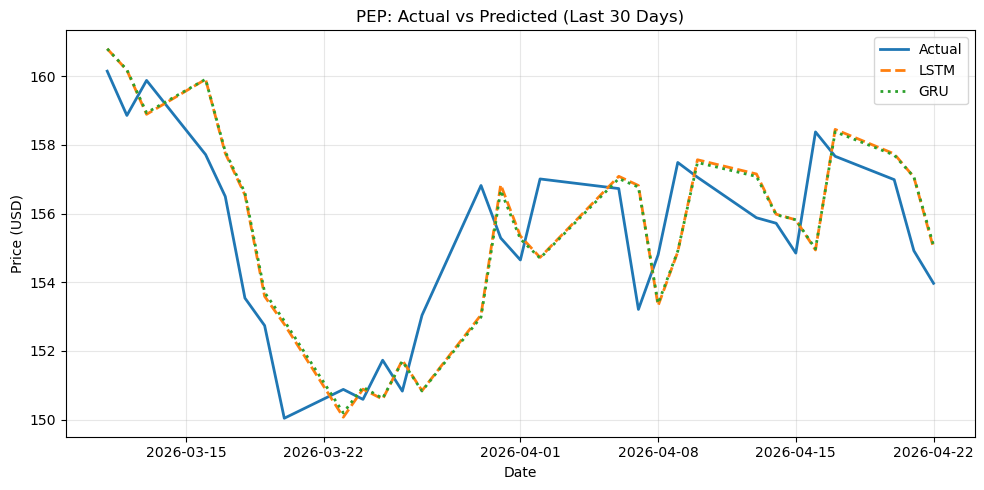

In [60]:
window = 30

lstm_subset = lstm_price_results.tail(window)
gru_subset = gru_price_results.tail(window)

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_subset.index,
    lstm_subset['PEP_Actual'],
    label='Actual',
    linewidth=2
)

plt.plot(
    lstm_subset.index,
    lstm_subset['PEP_Predicted'],
    label='LSTM',
    linestyle='--',
    linewidth=2
)

plt.plot(
    gru_subset.index,
    gru_subset['PEP_Predicted'],
    label='GRU',
    linestyle=':',
    linewidth=2
)

plt.title('PEP: Actual vs Predicted (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [62]:
import numpy as np

diff = np.abs(
    lstm_price_results['KO_Predicted'] - 
    gru_price_results['KO_Predicted']
)

print("Average difference:", diff.mean())
print("Max difference:", diff.max())

Average difference: 0.024828607505036116
Max difference: 0.12066587637394832


In [64]:
import pandas as pd

# Select last 10 days
window = 10

lstm_subset = lstm_price_results.tail(window)
gru_subset = gru_price_results.tail(window)

# Create comparison table
comparison_table = pd.DataFrame({
    "Date": lstm_subset.index,
    "Actual Price (KO)": lstm_subset['KO_Actual'],
    "LSTM Predicted (KO)": lstm_subset['KO_Predicted'],
    "GRU Predicted (KO)": gru_subset['KO_Predicted']
})

# Set Date as index
comparison_table.set_index("Date", inplace=True)

# Round values for presentation
comparison_table = comparison_table.round(2)

print(comparison_table)

            Actual Price (KO)  LSTM Predicted (KO)  GRU Predicted (KO)
Date                                                                  
2026-04-09              78.18                77.35               77.38
2026-04-10              77.47                78.24               78.23
2026-04-13              76.41                77.54               77.52
2026-04-14              75.90                76.48               76.48
2026-04-15              75.31                75.96               75.97
2026-04-16              75.18                75.37               75.39
2026-04-17              75.74                75.24               75.22
2026-04-20              75.48                75.79               75.80
2026-04-21              74.70                75.54               75.56
2026-04-22              74.76                74.75               74.80


In [66]:
import numpy as np

actual = lstm_price_results['KO_Actual'].values
pred   = lstm_price_results['KO_Predicted'].values

# Compare prediction(t) with actual(t-1)
lag_diff = np.abs(pred[1:] - actual[:-1])

print("Mean diff vs previous day:", lag_diff.mean())
print("Max diff vs previous day:", lag_diff.max())

Mean diff vs previous day: 0.04579990859572271
Max diff vs previous day: 0.13053272303807262


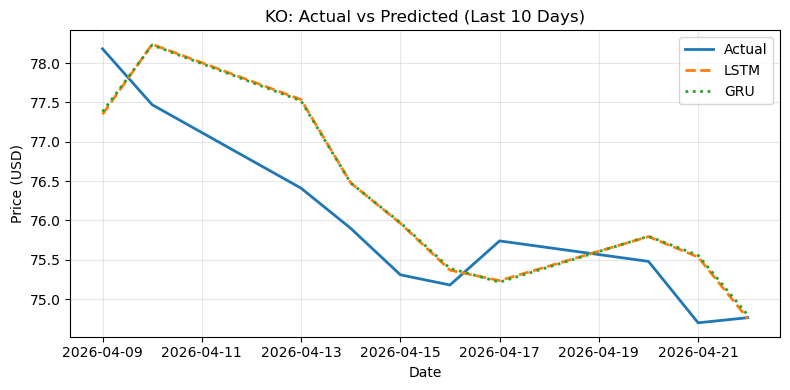

In [68]:
window = 10

lstm_subset = lstm_price_results.tail(window)
gru_subset = gru_price_results.tail(window)

plt.figure(figsize=(8,4))

plt.plot(lstm_subset.index, lstm_subset['KO_Actual'], label='Actual', linewidth=2)
plt.plot(lstm_subset.index, lstm_subset['KO_Predicted'], label='LSTM', linestyle='--', linewidth=2)
plt.plot(gru_subset.index, gru_subset['KO_Predicted'], label='GRU', linestyle=':', linewidth=2)

plt.title('KO: Actual vs Predicted (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

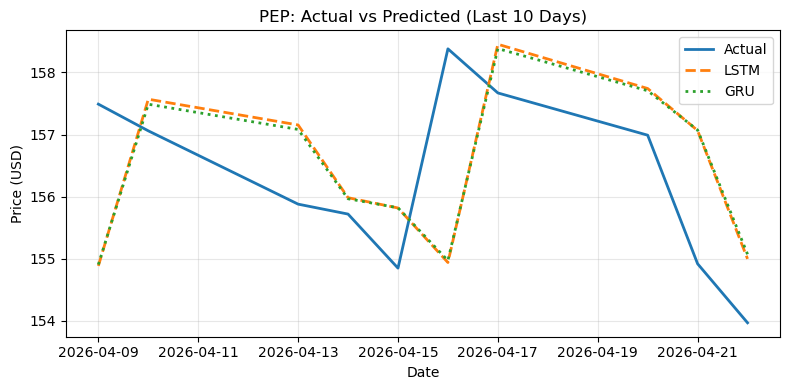

In [70]:
plt.figure(figsize=(8,4))

plt.plot(lstm_subset.index, lstm_subset['PEP_Actual'], label='Actual', linewidth=2)
plt.plot(lstm_subset.index, lstm_subset['PEP_Predicted'], label='LSTM', linestyle='--', linewidth=2)
plt.plot(gru_subset.index, gru_subset['PEP_Predicted'], label='GRU', linestyle=':', linewidth=2)

plt.title('PEP: Actual vs Predicted (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [72]:
import pandas as pd

# last 10 days
window = 10

lstm_subset = lstm_price_results.tail(window)
gru_subset = gru_price_results.tail(window)

combined_table = pd.DataFrame({
    "Date": lstm_subset.index.strftime("%Y-%m-%d"),

    "KO Actual": lstm_subset["KO_Actual"].round(2).values,
    "KO LSTM": lstm_subset["KO_Predicted"].round(2).values,
    "KO GRU": gru_subset["KO_Predicted"].round(2).values,

    "PEP Actual": lstm_subset["PEP_Actual"].round(2).values,
    "PEP LSTM": lstm_subset["PEP_Predicted"].round(2).values,
    "PEP GRU": gru_subset["PEP_Predicted"].round(2).values,
})

combined_table = combined_table.reset_index(drop=True)

# Display nicely
combined_table.style.hide(axis="index").set_caption(
    "Table X: Actual vs Predicted Prices for KO and PEP (Last 10 Days)"
).format({
    "KO Actual": "{:.2f}",
    "KO LSTM": "{:.2f}",
    "KO GRU": "{:.2f}",
    "PEP Actual": "{:.2f}",
    "PEP LSTM": "{:.2f}",
    "PEP GRU": "{:.2f}",
})

Date,KO Actual,KO LSTM,KO GRU,PEP Actual,PEP LSTM,PEP GRU
2026-04-09,78.18,77.35,77.38,157.49,154.89,154.91
2026-04-10,77.47,78.24,78.23,157.06,157.57,157.49
2026-04-13,76.41,77.54,77.52,155.88,157.15,157.08
2026-04-14,75.90,76.48,76.48,155.72,155.98,155.97
2026-04-15,75.31,75.96,75.97,154.85,155.82,155.82
2026-04-16,75.18,75.37,75.39,158.38,154.94,154.97
2026-04-17,75.74,75.24,75.22,157.67,158.45,158.38
2026-04-20,75.48,75.79,75.80,156.99,157.74,157.71
2026-04-21,74.70,75.54,75.56,154.92,157.06,157.07
2026-04-22,74.76,74.75,74.80,153.97,155.00,155.07


END